In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

In [2]:
df = pd.read_csv('superstore.csv')
df.dtypes

Row ID              int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID        object
Customer Name      object
Segment            object
Country/Region     object
City               object
State/Province     object
Postal Code        object
Region             object
Product ID         object
Category           object
Sub-Category       object
Product Name       object
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
dtype: object

In [3]:
df.shape

(10194, 21)

In [4]:
df.describe().round(2)

,Row ID,Sales,Quantity,Discount,Profit
count,10194.00,10194.00,10194.00,10194.00,10194.00
mean,5097.50,228.23,3.79,0.16,28.67
std,2942.90,619.91,2.23,0.21,232.47
min,1.00,0.44,1.00,0.00,-6599.98
25%,2549.25,17.22,2.00,0.00,1.76
50%,5097.50,53.91,3.00,0.20,8.69
75%,7645.75,209.50,5.00,0.20,29.30
max,10194.00,22638.48,14.00,0.80,8399.98


In [5]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [6]:
# Top Transaction
df[df['Sales'] > 20000]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
226,227,US-2023-145317,18-03-2023,23-03-2023,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,...,32216,South,TEC-MA-10002412,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,22638.48,6,0.5,-1811.0784


In [7]:
# Loss making Transactions
df[df['Profit'] < 0].sort_values('Profit')

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
6398,6399,US-2025-108196,25-11-2025,02-12-2025,Standard Class,CS-12505,Cindy Stewart,Consumer,United States,Lancaster,...,43130,East,TEC-MA-10000418,Technology,Machines,Cubify CubeX 3D Printer Double Head Print,4499.985,5,0.7,-6599.9780
9318,9319,US-2026-168116,04-11-2026,04-11-2026,Same Day,GT-14635,Grant Thornton,Corporate,United States,Burlington,...,27217,South,TEC-MA-10004125,Technology,Machines,Cubify CubeX 3D Printer Triple Head Print,7999.980,4,0.5,-3839.9904
821,822,US-2023-169019,26-07-2023,30-07-2023,Standard Class,LF-17185,Luke Foster,Consumer,United States,San Antonio,...,78207,Central,OFF-BI-10004995,Office Supplies,Binders,GBC DocuBind P400 Electric Binding System,2177.584,8,0.8,-3701.8928
7441,7442,US-2026-134845,17-04-2026,23-04-2026,Standard Class,SR-20425,Sharelle Roach,Home Office,United States,Louisville,...,80027,West,TEC-MA-10000822,Technology,Machines,Lexmark MX611dhe Monochrome Laser Printer,2549.985,5,0.7,-3399.9800
9845,9846,US-2026-122714,07-12-2026,13-12-2026,Standard Class,HG-14965,Henry Goldwyn,Corporate,United States,Chicago,...,60653,Central,OFF-BI-10001120,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,1889.990,5,0.8,-2929.4845
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2501,2502,US-2024-112130,03-05-2024,07-05-2024,Standard Class,SV-20785,Stewart Visinsky,Consumer,United States,Philadelphia,...,19140,East,TEC-AC-10001542,Technology,Accessories,SanDisk Cruzer 16 GB USB Flash Drive,27.552,3,0.2,-0.3444
7772,7773,US-2026-121125,30-05-2026,03-06-2026,Standard Class,MG-17890,Michael Granlund,Home Office,United States,Tigard,...,97224,West,FUR-FU-10000820,Furniture,Furnishings,Tensor Brushed Steel Torchiere Floor Lamp,13.592,1,0.2,-0.3398
3840,3841,US-2024-129112,29-11-2024,30-11-2024,First Class,AW-10840,Anthony Witt,Consumer,United States,Allen,...,75002,Central,TEC-AC-10003038,Technology,Accessories,Kingston Digital DataTraveler 16GB USB 2.0,21.480,3,0.2,-0.2685
8557,8558,US-2026-152485,04-09-2026,08-09-2026,Standard Class,JD-15790,John Dryer,Consumer,United States,Coppell,...,75019,Central,OFF-ST-10004950,Office Supplies,Storage,Acco Perma 3000 Stacking Storage Drawers,16.784,1,0.2,-0.2098


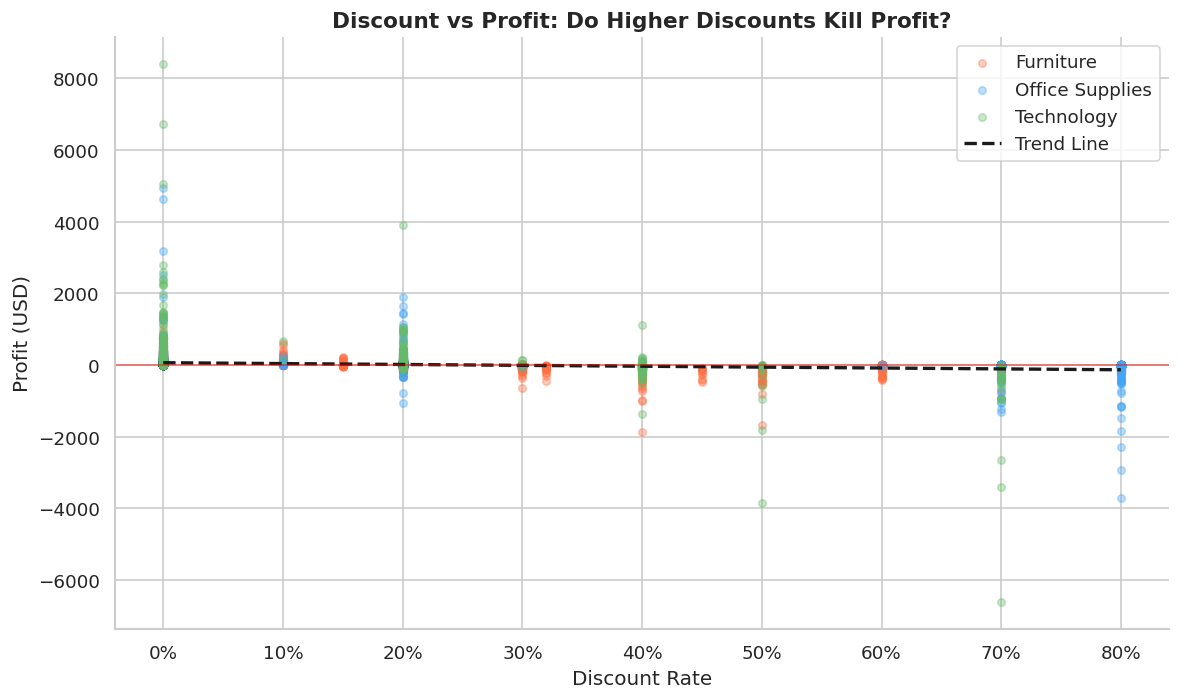

Correlation between Discount & Profit: -0.219
Insight: Clear negative correlation. Discounts above 40% almost always result in losses.
 
📌 Insight: There is a strong negative relationship between discount and profit.
Higher discount levels significantly reduce profitability, with many high-discount transactions resulting in losses.
This indicates that aggressive discounting is a key driver of negative profit in the business. 


In [8]:
# Discount Vs Profit
fig, ax = plt.subplots(figsize=(10, 6))

cat_palette = {'Furniture':'#FF7043','Office Supplies':'#42A5F5','Technology':'#66BB6A'}

for cat, grp in df.groupby('Category'):
    ax.scatter(grp['Discount'], grp['Profit'],
               alpha=0.35, s=20, label=cat, color=cat_palette[cat])

z = np.polyfit(df['Discount'], df['Profit'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, df['Discount'].max(), 100)
ax.plot(x_line, p(x_line), 'k--', linewidth=2, label='Trend Line')

ax.axhline(y=0, color='red', linewidth=1, linestyle='-', alpha=0.5)
ax.set_title('Discount vs Profit: Do Higher Discounts Kill Profit?', fontsize=13, fontweight='bold')
ax.set_xlabel('Discount Rate')
ax.set_ylabel('Profit (USD)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(frameon=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

corr = df['Discount'].corr(df['Profit'])
print(f'Correlation between Discount & Profit: {corr:.3f}')
print('Insight: Clear negative correlation. Discounts above 40% almost always result in losses.')
print(""" \n📌 Insight: There is a strong negative relationship between discount and profit.
Higher discount levels significantly reduce profitability, with many high-discount transactions resulting in losses.
This indicates that aggressive discounting is a key driver of negative profit in the business. """)

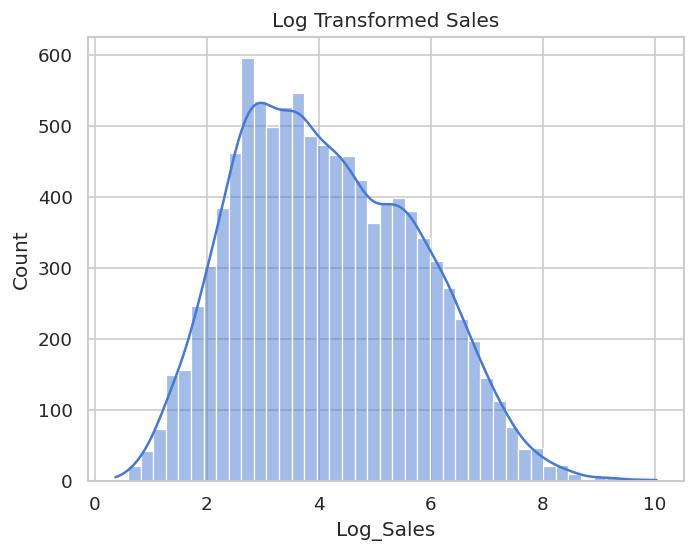


📌 Insight: The dataset contains significant outliers in sales and profit.
These are not data errors but represent high-value transactions and loss-making orders,
likely due to heavy discounts.
These outliers were retained for analysis as they provide critical business insights.


In [9]:
# Normalising values using Log Transformation
df['Log_Sales'] = np.log1p(df['Sales'])

sns.histplot(df['Log_Sales'], kde=True)
plt.title("Log Transformed Sales")
plt.show()
print("""\n📌 Insight: The dataset contains significant outliers in sales and profit.
These are not data errors but represent high-value transactions and loss-making orders,
likely due to heavy discounts.
These outliers were retained for analysis as they provide critical business insights.""")

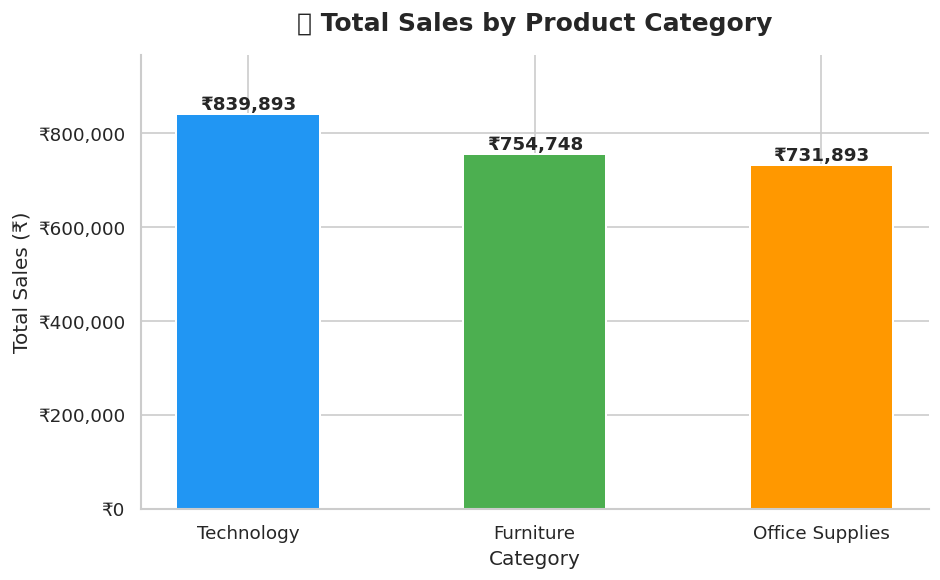

 
📌 Insight: Technology is the leading revenue-generating category,
while Furniture and Office Supplies contribute comparatively lower sales,
indicating a concentration of revenue in specific product segments.


In [10]:
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800']
bars = ax.bar(cat_sales.index, cat_sales.values, color=colors, edgecolor='white', linewidth=1.2, width=0.5)

for bar, val in zip(bars, cat_sales.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
            f'₹{val:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('💰 Total Sales by Product Category', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Total Sales (₹)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.set_ylim(0, cat_sales.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig('viz1_sales_by_category.png', bbox_inches='tight')
plt.show()

# Insight
print(""" \n📌 Insight: Technology is the leading revenue-generating category,
while Furniture and Office Supplies contribute comparatively lower sales,
indicating a concentration of revenue in specific product segments.""")

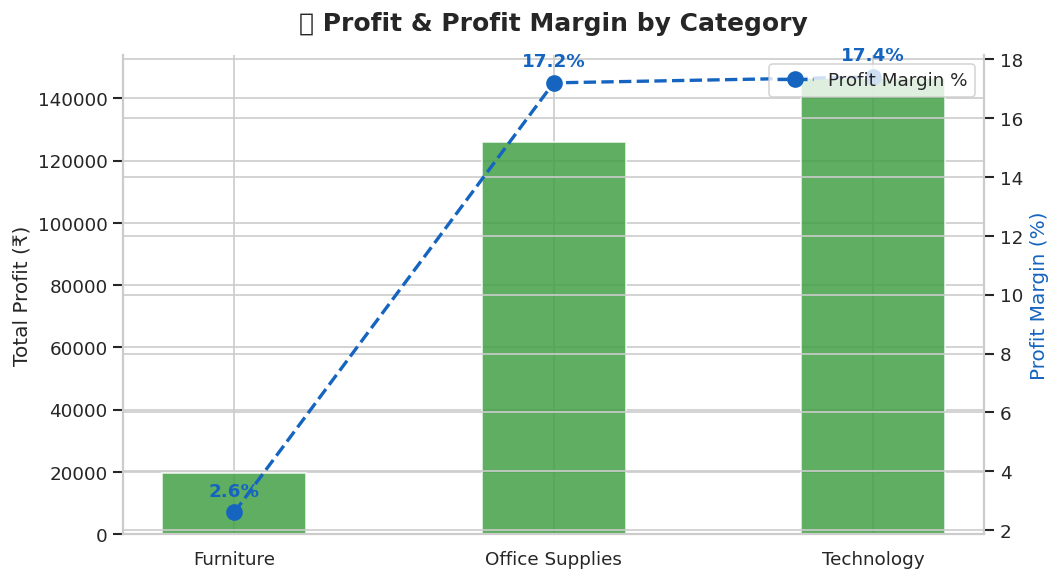


📌 Insight: Office Supplies has the highest profit margin despite lower total sales.


In [11]:
cat_profit = df.groupby('Category').agg({'Sales':'sum', 'Profit':'sum'}).reset_index()
cat_profit['Margin%'] = (cat_profit['Profit'] / cat_profit['Sales'] * 100).round(1)

fig, ax1 = plt.subplots(figsize=(9, 5))
bar_colors = ['#E53935' if p < 0 else '#43A047' for p in cat_profit['Profit']]
bars = ax1.bar(cat_profit['Category'], cat_profit['Profit'], color=bar_colors, alpha=0.85, width=0.45)

ax2 = ax1.twinx()
ax2.plot(cat_profit['Category'], cat_profit['Margin%'], 'o--', color='#1565C0',
         linewidth=2, markersize=9, label='Profit Margin %')
for i, (x, y) in enumerate(zip(cat_profit['Category'], cat_profit['Margin%'])):
    ax2.annotate(f'{y}%', (x, y), textcoords='offset points', xytext=(0, 10),
                 ha='center', fontweight='bold', color='#1565C0', fontsize=11)

ax1.set_title('📊 Profit & Profit Margin by Category', fontsize=15, fontweight='bold', pad=15)
ax1.set_ylabel('Total Profit (₹)', fontsize=12)
ax2.set_ylabel('Profit Margin (%)', fontsize=12, color='#1565C0')
ax2.legend(loc='upper right')
sns.despine(right=False)
plt.tight_layout()
plt.savefig('viz2_profit_by_category.png', bbox_inches='tight')
plt.show()
print('\n📌 Insight: Office Supplies has the highest profit margin despite lower total sales.')

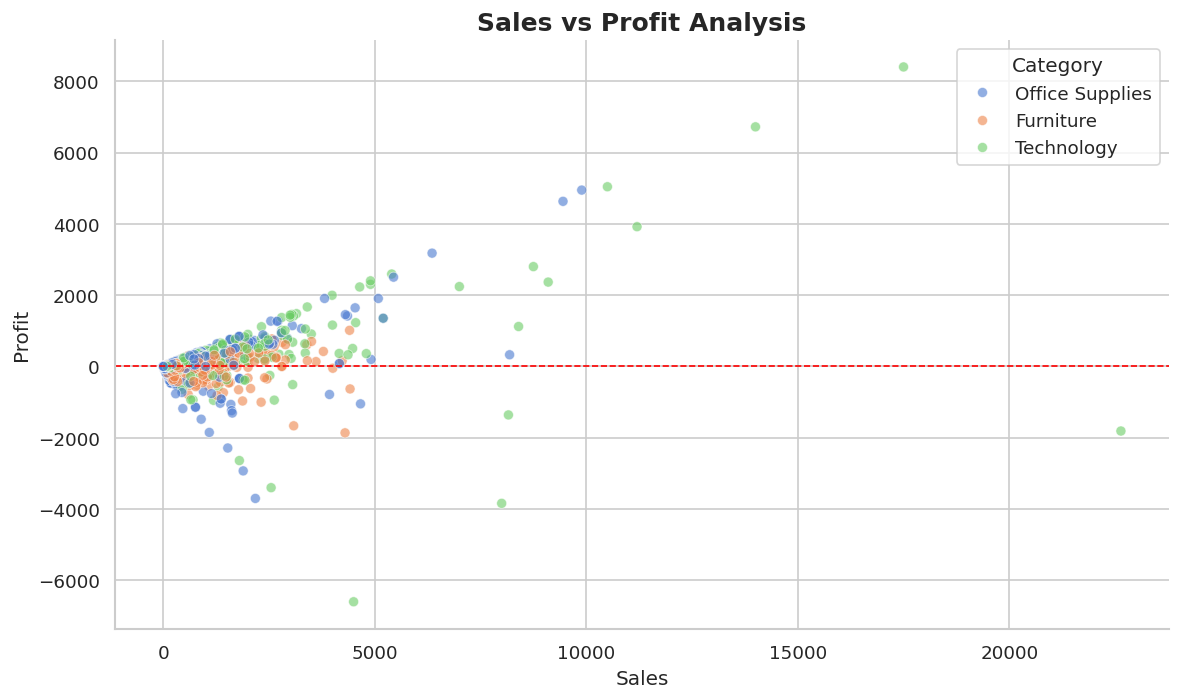

 
📌 Insight: The relationship between sales and profit reveals that 
higher sales do not always leads to higher profitability.
Several high-sales transactions result in negative profit,
indicating the impact of heavy discounts or low-margin products. 


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Sales',
    y='Profit',
    hue='Category',
    alpha=0.6
)

# Reference line at Profit = 0
plt.axhline(0, color='red', linestyle='--', linewidth=1)

# Titles and labels
plt.title('Sales vs Profit Analysis', fontsize=15, fontweight='bold')
plt.xlabel('Sales', fontsize=12)
plt.ylabel('Profit', fontsize=12)

plt.legend(title='Category')
sns.despine()
plt.tight_layout()

plt.savefig('sales_vs_profit.png', dpi=300)
plt.show()

print(""" \n📌 Insight: The relationship between sales and profit reveals that 
higher sales do not always leads to higher profitability.
Several high-sales transactions result in negative profit,
indicating the impact of heavy discounts or low-margin products. """)

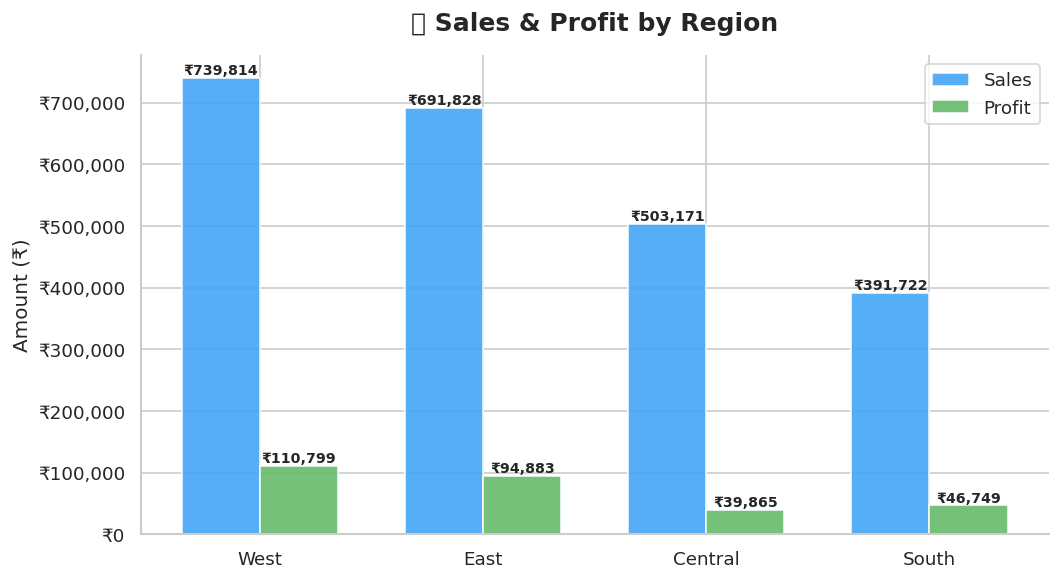


📌 Insight: West region dominates in both Sales and Profit. South region needs strategic attention.


In [13]:
region_data = df.groupby('Region').agg({'Sales':'sum','Profit':'sum'}).reset_index()
region_data = region_data.sort_values('Sales', ascending=False)

x = np.arange(len(region_data))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width/2, region_data['Sales'],   width, label='Sales',  color='#42A5F5', alpha=0.9)
b2 = ax.bar(x + width/2, region_data['Profit'],  width, label='Profit', color='#66BB6A', alpha=0.9)

for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
            f'₹{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
            f'₹{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_title('🗺️ Sales & Profit by Region', fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(region_data['Region'], fontsize=11)
ax.set_ylabel('Amount (₹)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.savefig('viz4_region_sales.png', bbox_inches='tight')
plt.show()
print('\n📌 Insight: West region dominates in both Sales and Profit. South region needs strategic attention.')

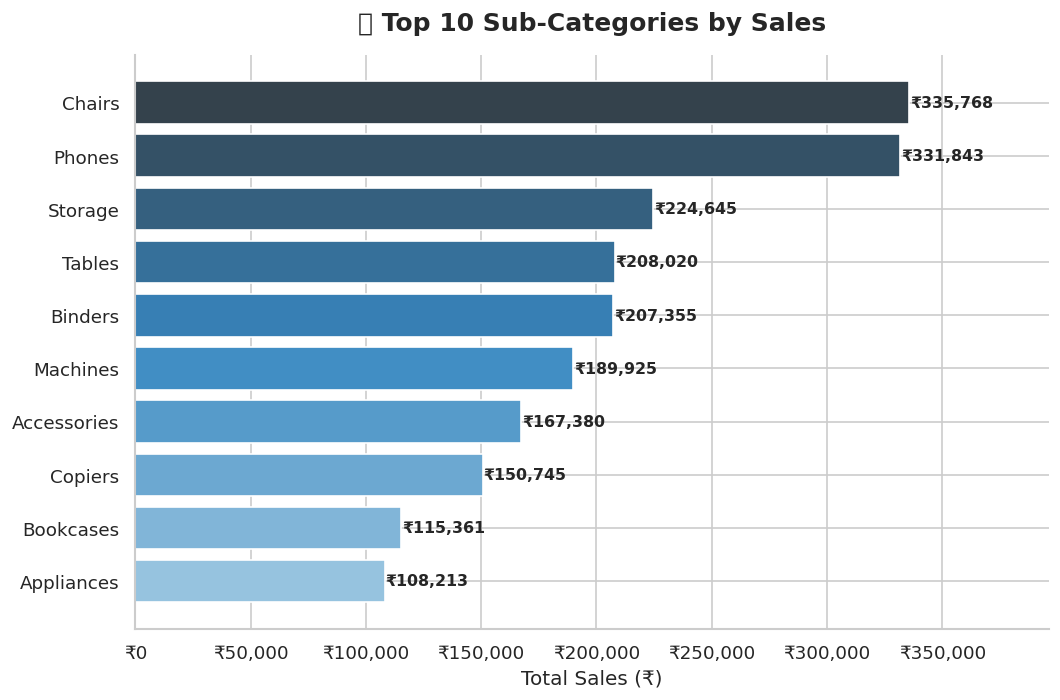


📌 Insight: Phones and Chairs are the top revenue-generating sub-categories.


In [14]:
sub_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(9, 6))
colors = sns.color_palette('Blues_d', len(sub_sales))
bars = ax.barh(sub_sales.index, sub_sales.values, color=colors, edgecolor='white')

for bar, val in zip(bars, sub_sales.values):
    ax.text(val + 300, bar.get_y() + bar.get_height()/2,
            f'₹{val:,.0f}', va='center', fontsize=9.5, fontweight='bold')

ax.set_title('🏆 Top 10 Sub-Categories by Sales', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Total Sales (₹)', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.set_xlim(0, sub_sales.max() * 1.18)
sns.despine()
plt.tight_layout()
plt.savefig('viz5_top_subcategories.png', bbox_inches='tight')
plt.show()
print('\n📌 Insight: Phones and Chairs are the top revenue-generating sub-categories.')

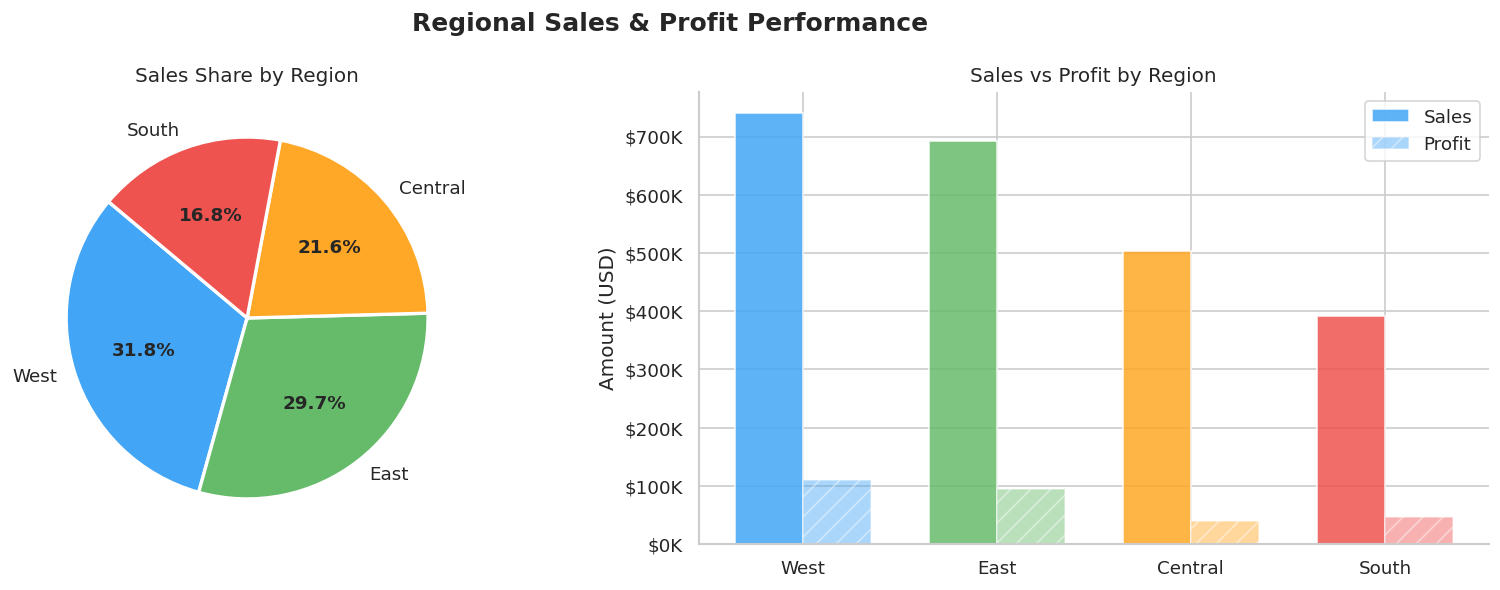

Insight: West region leads in sales. Central region shows lower profit margins relative to sales volume.


In [15]:
reg = df.groupby('Region')[['Sales','Profit']].sum().sort_values('Sales', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Regional Sales & Profit Performance', fontsize=15, fontweight='bold')

region_colors = ['#42A5F5','#66BB6A','#FFA726','#EF5350']

wedges, texts, autotexts = axes[0].pie(
    reg['Sales'], labels=reg.index, autopct='%1.1f%%',
    colors=region_colors, startangle=140,
    wedgeprops={'edgecolor':'white','linewidth':2},
    textprops={'fontsize':11}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[0].set_title('Sales Share by Region')

x = np.arange(len(reg))
w = 0.35
axes[1].bar(x - w/2, reg['Sales'], w, label='Sales', color=region_colors, alpha=0.85)
axes[1].bar(x + w/2, reg['Profit'], w, label='Profit', color=region_colors, alpha=0.45, hatch='//')
axes[1].set_xticks(x)
axes[1].set_xticklabels(reg.index)
axes[1].set_title('Sales vs Profit by Region')
axes[1].set_ylabel('Amount (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print('Insight: West region leads in sales. Central region shows lower profit margins relative to sales volume.')

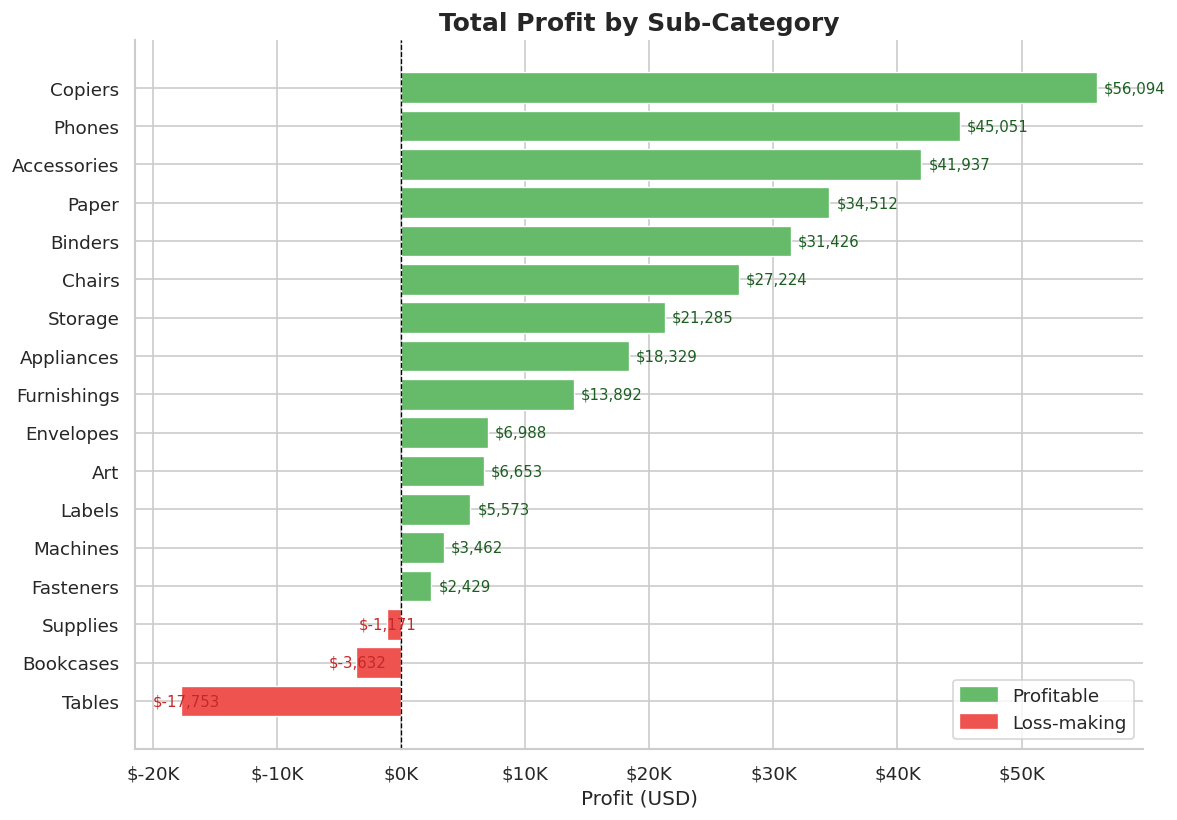

 
📌 Insight: Profitability varies significantly across sub-categories.
While products like Phones and Copiers generate strong profits, categories such as Tables and Bookcases consistently incur losses.
This indicates inefficiencies in pricing or cost management within specific product segments. 


In [16]:
sub = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors = ['#EF5350' if p < 0 else '#66BB6A' for p in sub]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(sub.index, sub.values, color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, sub.values):
    x_pos = val + (max(sub)*0.01) if val >= 0 else val - (max(sub)*0.04)
    ax.text(x_pos, bar.get_y()+bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=9,
            color='#C62828' if val < 0 else '#1B5E20')

ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Total Profit by Sub-Category', fontsize=15, fontweight='bold')
ax.set_xlabel('Profit (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#66BB6A',label='Profitable'), Patch(color='#EF5350',label='Loss-making')],
          loc='lower right')

plt.tight_layout()
plt.show()

print(""" \n📌 Insight: Profitability varies significantly across sub-categories.
While products like Phones and Copiers generate strong profits, categories such as Tables and Bookcases consistently incur losses.
This indicates inefficiencies in pricing or cost management within specific product segments. """)

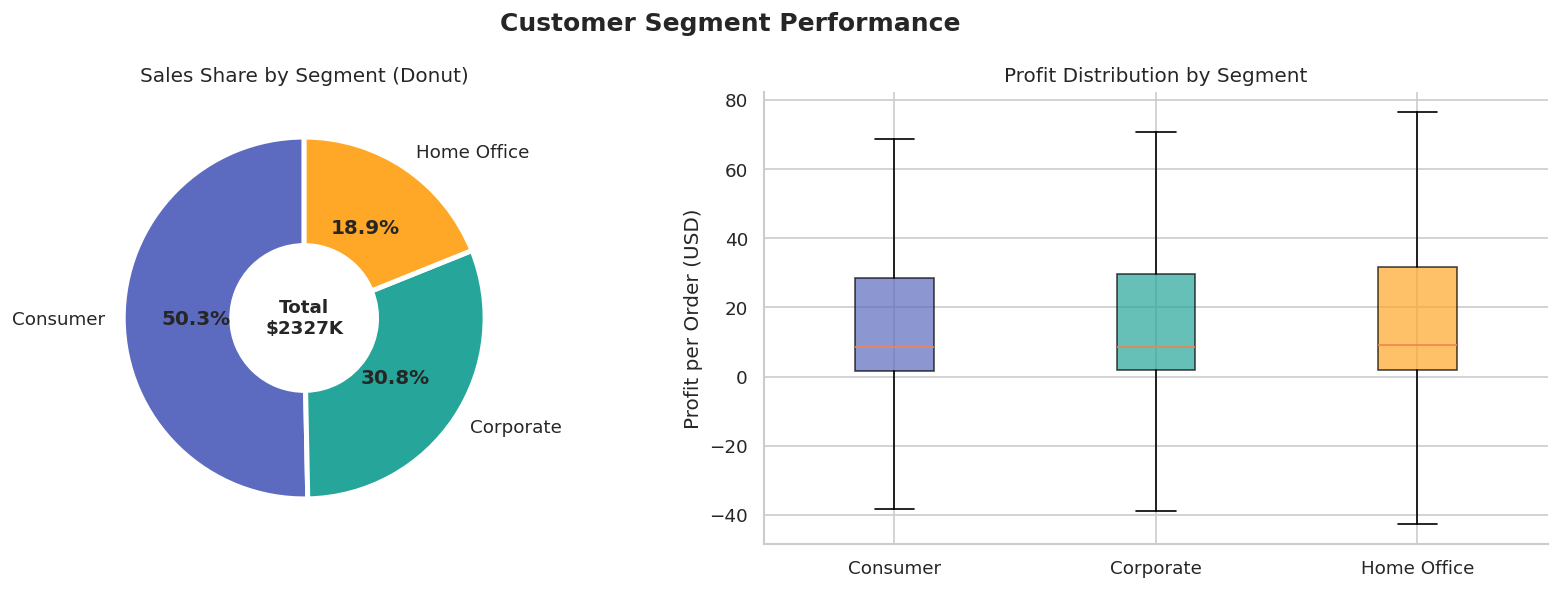

Insight: Consumer segment drives the most total sales. Corporate has a tighter profit distribution, indicating reliable bulk-order behavior.


In [17]:
seg_data = df.groupby('Segment')[['Sales','Profit']].sum().reset_index()
seg_colors = ['#5C6BC0','#26A69A','#FFA726']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Customer Segment Performance', fontsize=15, fontweight='bold')

wedges, texts, autotexts = axes[0].pie(
    seg_data['Sales'], labels=seg_data['Segment'],
    autopct='%1.1f%%', colors=seg_colors, startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':3, 'width':0.6}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[0].set_title('Sales Share by Segment (Donut)')
axes[0].text(0, 0, f'Total\n${df["Sales"].sum()/1000:.0f}K',
             ha='center', va='center', fontsize=11, fontweight='bold')

seg_order = ['Consumer','Corporate','Home Office']
seg_plot_data = [df[df['Segment']==s]['Profit'].values for s in seg_order]
bp = axes[1].boxplot(seg_plot_data, patch_artist=True, labels=seg_order,
                      notch=False, showfliers=False)
for patch, color in zip(bp['boxes'], seg_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Profit Distribution by Segment')
axes[1].set_ylabel('Profit per Order (USD)')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print('Insight: Consumer segment drives the most total sales. Corporate has a tighter profit distribution, indicating reliable bulk-order behavior.')

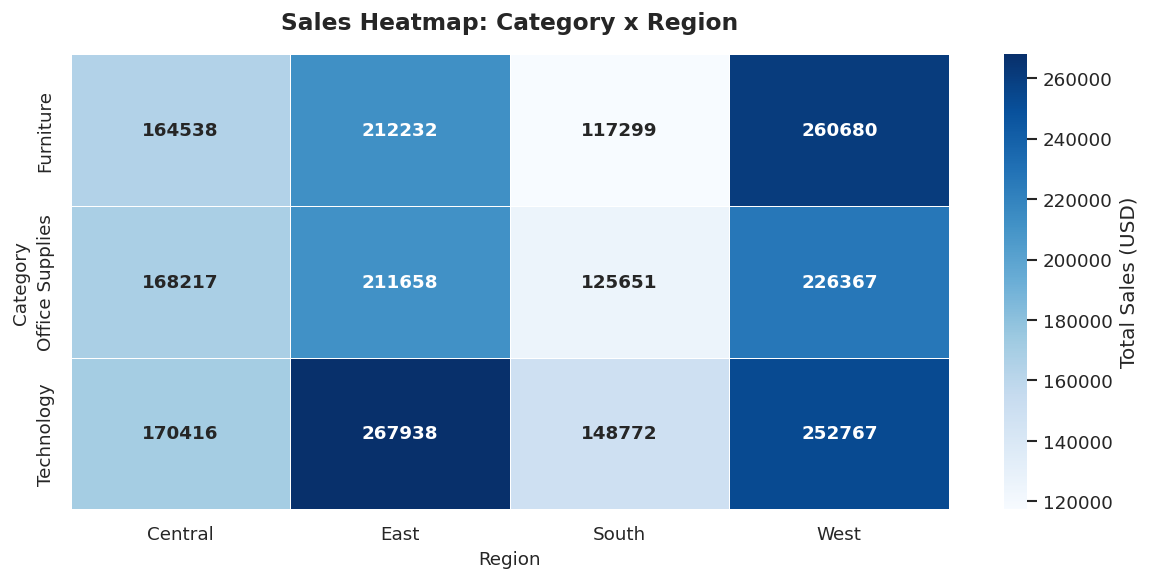

Insight: Technology sales are highest in the West. Central region consistently lags across all categories.


In [18]:
pivot = df.pivot_table(values='Sales', index='Category', columns='Region', aggfunc='sum')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, linecolor='white',
            annot_kws={'size':11, 'weight':'bold'},
            ax=ax, cbar_kws={'label': 'Total Sales (USD)'})

ax.set_title('Sales Heatmap: Category x Region', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Region', fontsize=11)
ax.set_ylabel('Category', fontsize=11)

plt.tight_layout()
plt.show()

print('Insight: Technology sales are highest in the West. Central region consistently lags across all categories.')

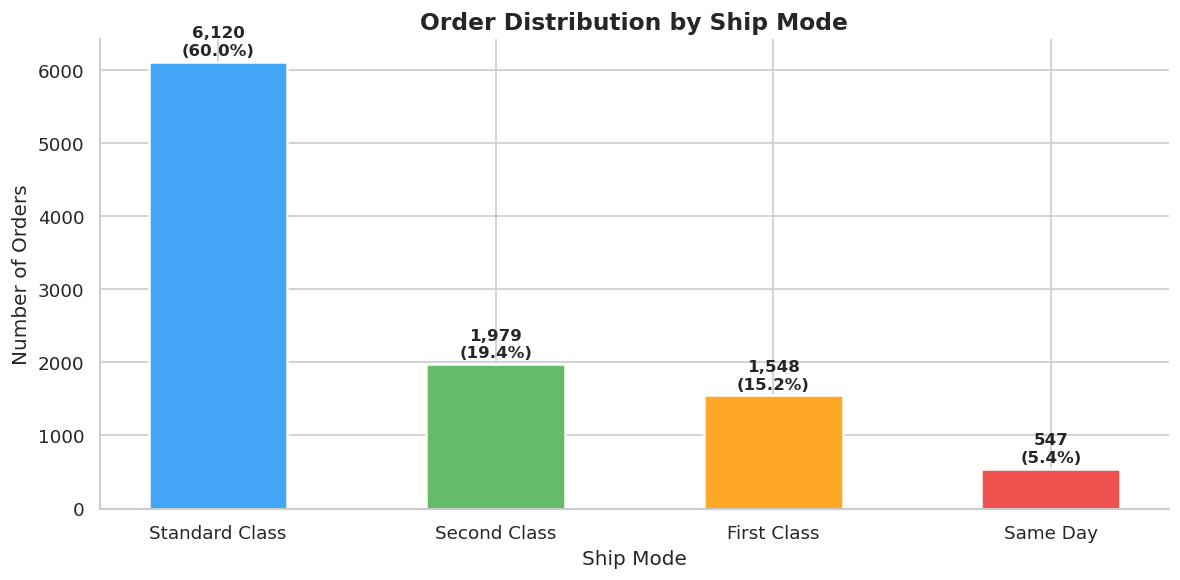

Insight: Over 60% of orders use Standard Class shipping. Same Day delivery is rarely used — a potential premium upsell opportunity.


In [19]:
ship_counts = df['Ship Mode'].value_counts().reset_index()
ship_counts.columns = ['Ship Mode','Count']
ship_colors = ['#42A5F5','#66BB6A','#FFA726','#EF5350']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(ship_counts['Ship Mode'], ship_counts['Count'],
               color=ship_colors, edgecolor='white', linewidth=1.5, width=0.5)

for bar in bars:
    pct = bar.get_height() / len(df) * 100
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            f'{bar.get_height():,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_title('Order Distribution by Ship Mode', fontsize=14, fontweight='bold')
ax.set_xlabel('Ship Mode')
ax.set_ylabel('Number of Orders')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print('Insight: Over 60% of orders use Standard Class shipping. Same Day delivery is rarely used — a potential premium upsell opportunity.')

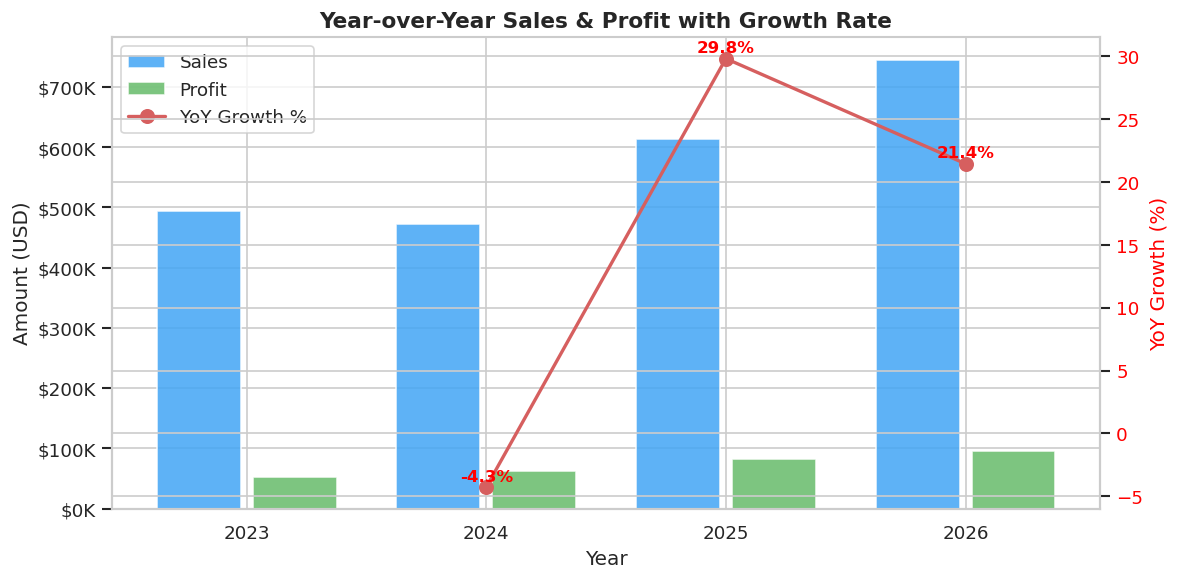

Insight: The business shows consistent year-over-year sales and profit growth, indicating a healthy and expanding operation.


In [20]:
# Year-over-Year Sales
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.month_name()

yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()

yearly_sales['YoY Growth (%)'] = yearly_sales['Sales'].pct_change() * 100

yearly = df.groupby('Year')[['Sales','Profit']].sum().reset_index()
yearly['Growth%'] = yearly['Sales'].pct_change() * 100

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

x = np.arange(len(yearly))
ax1.bar(x - 0.2, yearly['Sales'], 0.35, label='Sales', color='#42A5F5', alpha=0.85)
ax1.bar(x + 0.2, yearly['Profit'], 0.35, label='Profit', color='#66BB6A', alpha=0.85)

ax2.plot(x[1:], yearly['Growth%'].dropna(), 'ro-', linewidth=2, markersize=8, label='YoY Growth %')
for xi, g in zip(x[1:], yearly['Growth%'].dropna()):
    ax2.text(xi, g+0.5, f'{g:.1f}%', ha='center', fontsize=10, color='red', fontweight='bold')

ax1.set_title('Year-over-Year Sales & Profit with Growth Rate', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(yearly['Year'])
ax1.set_xlabel('Year')
ax1.set_ylabel('Amount (USD)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax2.set_ylabel('YoY Growth (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
ax1.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

print('Insight: The business shows consistent year-over-year sales and profit growth, indicating a healthy and expanding operation.')

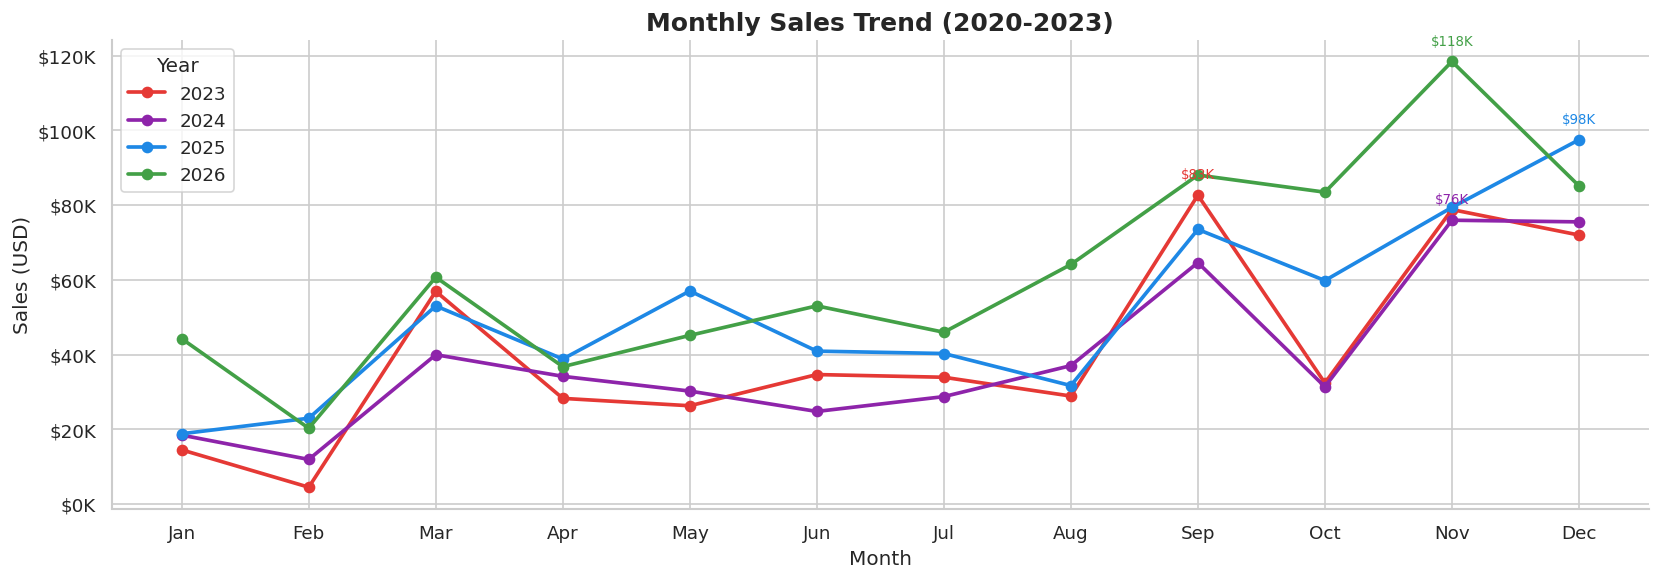

Insight: Sales consistently peak in Q4 (Nov-Dec), suggesting strong holiday/year-end demand across all years.


In [21]:
monthly = df.groupby(['Year','Month'])['Sales'].sum().reset_index()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 5))
palette = ['#E53935','#8E24AA','#1E88E5','#43A047']

for i, year in enumerate(sorted(monthly['Year'].unique())):
    yd = monthly[monthly['Year']==year].sort_values('Month')
    ax.plot(yd['Month'], yd['Sales'], marker='o', linewidth=2.2,
            markersize=6, label=str(year), color=palette[i])
    peak = yd.loc[yd['Sales'].idxmax()]
    ax.annotate(f"${peak['Sales']/1000:.0f}K",
                xy=(peak['Month'], peak['Sales']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=8, color=palette[i])

ax.set_title('Monthly Sales Trend (2020-2023)', fontsize=15, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Sales (USD)')
ax.set_xticks(range(1,13))
ax.set_xticklabels(month_labels)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(title='Year', frameon=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print('Insight: Sales consistently peak in Q4 (Nov-Dec), suggesting strong holiday/year-end demand across all years.')

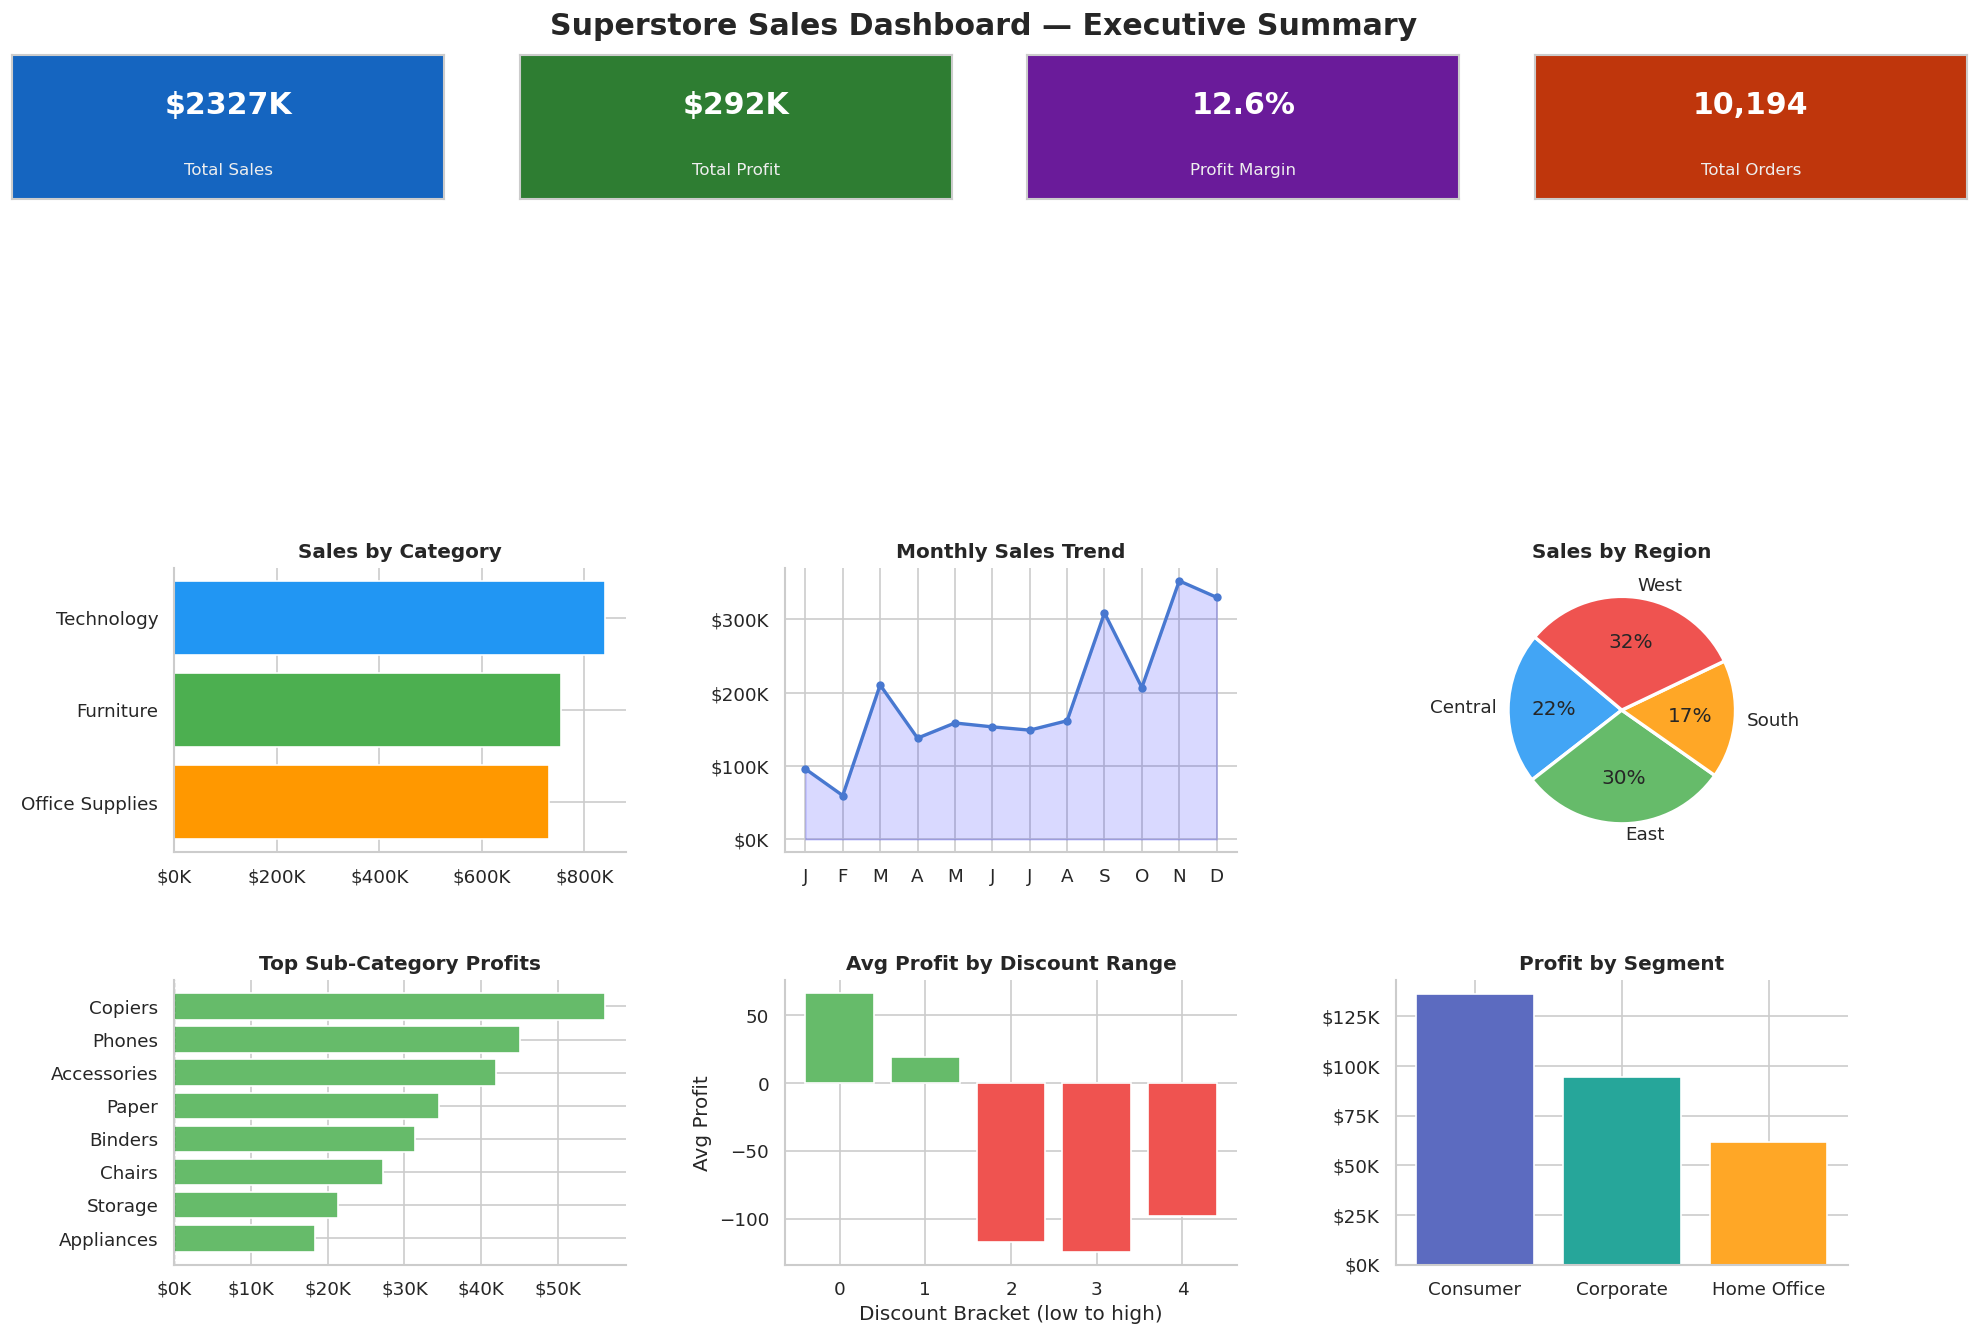

In [23]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Superstore Sales Dashboard — Executive Summary',
             fontsize=18, fontweight='bold', y=0.98)

# KPI Boxes
kpis = [
    (f"${df['Sales'].sum()/1000:.0f}K",  'Total Sales',   '#1565C0'),
    (f"${df['Profit'].sum()/1000:.0f}K", 'Total Profit',  '#2E7D32'),
    (f"{df['Profit'].sum()/df['Sales'].sum()*100:.1f}%", 'Profit Margin', '#6A1B9A'),
    (f"{len(df):,}",                     'Total Orders',  '#BF360C'),
]
for i, (val, label, color) in enumerate(kpis):
    ax_kpi = fig.add_axes([0.05 + i*0.235, 0.85, 0.20, 0.10])
    ax_kpi.set_facecolor(color)
    ax_kpi.text(0.5, 0.65, val, transform=ax_kpi.transAxes,
                ha='center', va='center', fontsize=18, fontweight='bold', color='white')
    ax_kpi.text(0.5, 0.20, label, transform=ax_kpi.transAxes,
                ha='center', va='center', fontsize=10, color='#EEEEEE')
    ax_kpi.set_xticks([]); ax_kpi.set_yticks([])

# Panel 1: Category Sales
ax1 = fig.add_subplot(3, 3, 4)
cat_s = df.groupby('Category')['Sales'].sum().sort_values()
ax1.barh(cat_s.index, cat_s.values, color=['#FF9800','#4CAF50','#2196F3'])
ax1.set_title('Sales by Category', fontweight='bold')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# Panel 2: Monthly Trend
ax2 = fig.add_subplot(3, 3, 5)
monthly_all = df.groupby('Month')['Sales'].sum()
ax2.plot(monthly_all.index, monthly_all.values, 'b-o', markersize=4, linewidth=2)
ax2.fill_between(monthly_all.index, monthly_all.values, alpha=0.15, color='blue')
ax2.set_title('Monthly Sales Trend', fontweight='bold')
ax2.set_xticks(range(1,13))
ax2.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

# Panel 3: Region Pie
ax3 = fig.add_subplot(3, 3, 6)
reg_s = df.groupby('Region')['Sales'].sum()
ax3.pie(reg_s, labels=reg_s.index, autopct='%1.0f%%',
        colors=['#42A5F5','#66BB6A','#FFA726','#EF5350'],
        startangle=140, wedgeprops={'edgecolor':'white','linewidth':2})
ax3.set_title('Sales by Region', fontweight='bold')

# Panel 4: Sub-cat Profit
ax4 = fig.add_subplot(3, 3, 7)
sub_p = df.groupby('Sub-Category')['Profit'].sum().sort_values().tail(8)
colors_sub = ['#EF5350' if p<0 else '#66BB6A' for p in sub_p]
ax4.barh(sub_p.index, sub_p.values, color=colors_sub)
ax4.axvline(0, color='black', linewidth=0.7, linestyle='--')
ax4.set_title('Top Sub-Category Profits', fontweight='bold')
ax4.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax4.spines['top'].set_visible(False); ax4.spines['right'].set_visible(False)

# Panel 5: Discount impact
ax5 = fig.add_subplot(3, 3, 8)
disc_bins = df.groupby(pd.cut(df['Discount'], bins=5))['Profit'].mean()
ax5.bar(range(len(disc_bins)), disc_bins.values,
        color=['#66BB6A' if v>0 else '#EF5350' for v in disc_bins.values])
ax5.set_title('Avg Profit by Discount Range', fontweight='bold')
ax5.set_xlabel('Discount Bracket (low to high)')
ax5.set_ylabel('Avg Profit')
ax5.spines['top'].set_visible(False); ax5.spines['right'].set_visible(False)

# Panel 6: Segment Profit
ax6 = fig.add_subplot(3, 3, 9)
seg_p = df.groupby('Segment')['Profit'].sum()
ax6.bar(seg_p.index, seg_p.values, color=['#5C6BC0','#26A69A','#FFA726'])
ax6.set_title('Profit by Segment', fontweight='bold')
ax6.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax6.spines['top'].set_visible(False); ax6.spines['right'].set_visible(False)

plt.subplots_adjust(hspace=0.45, wspace=0.35)
plt.show()